In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/processed/telco_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded: 7,043 rows, 22 columns


### Group 1 — Financial features
 
**`charge_per_tenure`**: total charges divided by tenure — the customer's average
monthly spend over their actual lifetime. For new customers (tenure=0), we fall
back to MonthlyCharges to avoid division by zero.
 
**`monthly_charge_bin`**: quartile bucket (1–4). Lets the model use charge level
as an ordinal category rather than a raw float.
 
**`high_value_flag`**: 1 if MonthlyCharges exceeds the 75th percentile (~$89.85).
From EDA: churned customers pay $13/month more on average — this flag captures
the high-value segment that is disproportionately at risk.


In [2]:
df["charge_per_tenure"] = (
    df["TotalCharges"] / df["tenure"].replace(0, np.nan)
).fillna(df["MonthlyCharges"])
 
df["monthly_charge_bin"] = pd.qcut(
    df["MonthlyCharges"], q=4, labels=[1, 2, 3, 4]
).astype(int)
 
high_value_threshold = df["MonthlyCharges"].quantile(0.75)
df["high_value_flag"] = (df["MonthlyCharges"] > high_value_threshold).astype(int)
 
print(f"75th percentile threshold: ${high_value_threshold:.2f}")
print(f"High-value customers: {df['high_value_flag'].sum():,} ({df['high_value_flag'].mean()*100:.1f}%)")
print(f"\nChurn rate by monthly_charge_bin:")
print(df.groupby("monthly_charge_bin")["Churn"].mean().mul(100).round(1).astype(str) + "%")

75th percentile threshold: $89.85
High-value customers: 1,758 (25.0%)

Churn rate by monthly_charge_bin:
monthly_charge_bin
1    11.2%
2    24.6%
3    37.5%
4    32.9%
Name: Churn, dtype: str


### Group 2 — Tenure features
 
**`tenure_bucket`**: four lifecycle stages — new (0–12m), developing (13–24m),
established (25–48m), loyal (49–72m). From EDA, churn drops from 47.7% to 9.5%
across these stages.
 
**`is_new_customer`**: binary flag for the highest-risk window (tenure ≤ 12 months).
Nearly 1 in 2 new customers churns.
 
**`is_loyal_customer`**: binary flag for the lowest-risk group (tenure ≥ 48 months).
Useful for filtering retention campaigns away from customers who are already stable.

In [3]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["new", "developing", "established", "loyal"],
    include_lowest=True
)
 
df["is_new_customer"]   = (df["tenure"] <= 12).astype(int)
df["is_loyal_customer"] = (df["tenure"] >= 48).astype(int)
 
print("Churn rate by tenure_bucket:")
print(df.groupby("tenure_bucket", observed=True)["Churn"].mean().mul(100).round(1).astype(str) + "%")
print(f"\nNew customers (≤12m): {df['is_new_customer'].sum():,} — churn rate: {df[df['is_new_customer']==1]['Churn'].mean()*100:.1f}%")
print(f"Loyal customers (≥48m): {df['is_loyal_customer'].sum():,} — churn rate: {df[df['is_loyal_customer']==1]['Churn'].mean()*100:.1f}%")

Churn rate by tenure_bucket:
tenure_bucket
new            47.4%
developing     28.7%
established    20.4%
loyal           9.5%
Name: Churn, dtype: str

New customers (≤12m): 2,186 — churn rate: 47.4%
Loyal customers (≥48m): 2,303 — churn rate: 9.6%


### Group 3 — Contract & payment features
 
**`contract_risk_score`**: ordinal encoding of contract type.
Month-to-month=2, One year=1, Two year=0.
Encodes the 15x churn rate difference into a single numeric feature.
 
**`is_autopay`**: 1 if the customer uses bank transfer or credit card auto-pay.
Auto-pay customers churn at ~16% vs 35% for non-auto-pay — a strong signal that
also acts as a proxy for customer engagement and commitment.
 
**`paperless_billing`**: binary encode of PaperlessBilling.

In [4]:
df["contract_risk_score"] = df["Contract"].map({
    "Month-to-month": 2,
    "One year":        1,
    "Two year":        0,
})
 
df["is_autopay"] = df["PaymentMethod"].isin(
    {"Bank transfer (automatic)", "Credit card (automatic)"}
).astype(int)
 
df["paperless_billing"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})
 
print("Churn rate by contract_risk_score:")
print(df.groupby("contract_risk_score")["Churn"].mean().mul(100).round(1).astype(str) + "%")
print(f"\nAuto-pay churn rate : {df[df['is_autopay']==1]['Churn'].mean()*100:.1f}%")
print(f"Non-auto-pay churn rate: {df[df['is_autopay']==0]['Churn'].mean()*100:.1f}%")

Churn rate by contract_risk_score:
contract_risk_score
0     2.8%
1    11.3%
2    42.7%
Name: Churn, dtype: str

Auto-pay churn rate : 16.0%
Non-auto-pay churn rate: 34.7%


### Group 4 — Service adoption features
 
**`addon_count`**: number of active add-on services out of 6 (OnlineSecurity,
OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies).
More services = more embedded in the product = lower churn risk.
 
**`has_protection`**: 1 if customer has OnlineSecurity OR TechSupport.
These are the stickiest services — customers with protection services are
significantly less likely to leave.
 
**`is_streaming_only`**: 1 if the customer uses streaming services but has no
security or support add-ons. These customers use the network like a utility
rather than being embedded in the ecosystem.
 
**`fiber_no_protection`**: interaction flag combining the fiber optic anomaly
from EDA with lack of protection services. This is the single highest-risk
combination in the dataset — 55% churn rate.

In [5]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
 
df["addon_count"] = sum((df[col] == "Yes").astype(int) for col in addon_cols)
 
df["has_protection"] = (
    (df["OnlineSecurity"] == "Yes") | (df["TechSupport"] == "Yes")
).astype(int)
 
df["is_streaming_only"] = (
    ((df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")) &
    (df["has_protection"] == 0)
).astype(int)
 
df["fiber_no_protection"] = (
    (df["InternetService"] == "Fiber optic") & (df["has_protection"] == 0)
).astype(int)
 
print("Churn rate by addon_count:")
print(df.groupby("addon_count")["Churn"].mean().mul(100).round(1).astype(str) + "%")
print(f"\nfiber_no_protection churn rate : {df[df['fiber_no_protection']==1]['Churn'].mean()*100:.1f}%")
print(f"Everyone else churn rate       : {df[df['fiber_no_protection']==0]['Churn'].mean()*100:.1f}%")

Churn rate by addon_count:
addon_count
0    21.4%
1    45.8%
2    35.8%
3    27.4%
4    22.3%
5    12.4%
6     5.3%
Name: Churn, dtype: str

fiber_no_protection churn rate : 55.0%
Everyone else churn rate       : 17.0%


### Group 5 — Demographic features
 
**`is_senior`**: already present as 0/1 — renaming for clarity. Seniors churn
at 41.7% vs 23.6% for non-seniors.
 
**`has_dependents`** / **`has_partner`**: binary encodings of Dependents and Partner.
 
**`is_independent`**: 1 if no partner AND no dependents. Independent customers
have fewer switching costs — easier to leave.

In [6]:
df["is_senior"]      = df["SeniorCitizen"].astype(int)
df["has_dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["has_partner"]    = df["Partner"].map({"Yes": 1, "No": 0})
df["is_independent"] = ((df["has_partner"] == 0) & (df["has_dependents"] == 0)).astype(int)
 
print(f"Senior churn rate      : {df[df['is_senior']==1]['Churn'].mean()*100:.1f}%")
print(f"Independent churn rate : {df[df['is_independent']==1]['Churn'].mean()*100:.1f}%")

Senior churn rate      : 41.7%
Independent churn rate : 34.2%


### Feature validation — churn rates across all engineered features
 
The chart below shows the churn rate at both levels of each binary feature.
Strong features show a wide gap between bars. This is a visual sanity check
before modeling — every feature should show a meaningful difference.

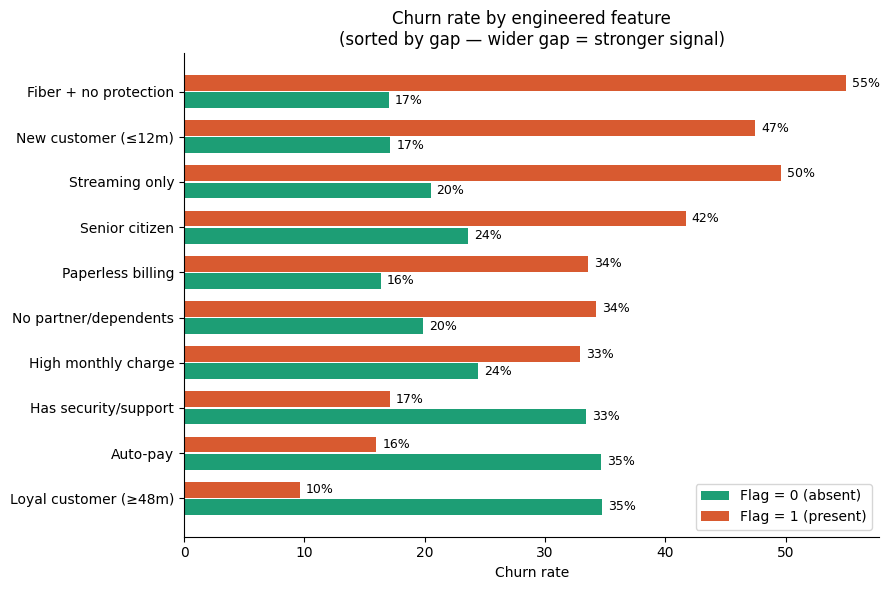

In [8]:
binary_features = [
    ("is_new_customer",      "New customer (≤12m)"),
    ("is_loyal_customer",    "Loyal customer (≥48m)"),
    ("high_value_flag",      "High monthly charge"),
    ("contract_risk_score",  None),   # skip — ordinal, plotted separately
    ("is_autopay",           "Auto-pay"),
    ("paperless_billing",    "Paperless billing"),
    ("has_protection",       "Has security/support"),
    ("is_streaming_only",    "Streaming only"),
    ("fiber_no_protection",  "Fiber + no protection"),
    ("is_senior",            "Senior citizen"),
    ("is_independent",       "No partner/dependents"),
]
 
rows = []
for col, label in binary_features:
    if label is None:
        continue
    rate_0 = df[df[col] == 0]["Churn"].mean() * 100
    rate_1 = df[df[col] == 1]["Churn"].mean() * 100
    rows.append({"feature": label, "flag=0": rate_0, "flag=1": rate_1, "gap": rate_1 - rate_0})
 
feat_df = pd.DataFrame(rows).sort_values("gap", ascending=True)
 
fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(feat_df))
ax.barh(y, feat_df["flag=0"], height=0.35, label="Flag = 0 (absent)",
        color="#1D9E75", align="center")
ax.barh([i + 0.38 for i in y], feat_df["flag=1"], height=0.35, label="Flag = 1 (present)",
        color="#D85A30", align="center")
 
for i, (_, row) in enumerate(feat_df.iterrows()):
    ax.text(row["flag=1"] + 0.5, i + 0.38, f"{row['flag=1']:.0f}%", va="center", fontsize=9)
    ax.text(row["flag=0"] + 0.5, i,        f"{row['flag=0']:.0f}%", va="center", fontsize=9)
 
ax.set_yticks([i + 0.19 for i in y])
ax.set_yticklabels(feat_df["feature"], fontsize=10)
ax.set_xlabel("Churn rate")
ax.set_title("Churn rate by engineered feature\n(sorted by gap — wider gap = stronger signal)")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

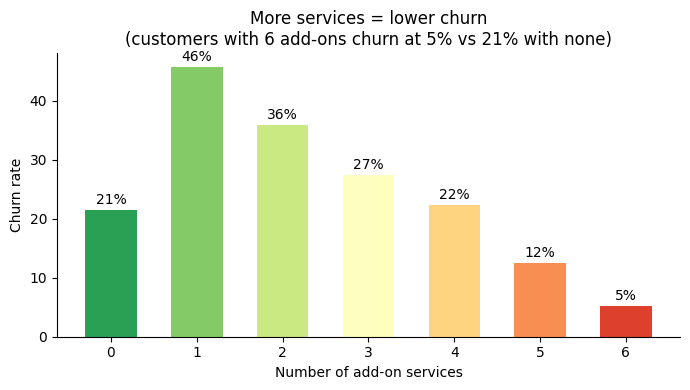

In [9]:
addon_churn = df.groupby("addon_count")["Churn"].mean() * 100
 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(addon_churn.index, addon_churn.values,
              color=sns.color_palette("RdYlGn", len(addon_churn))[::-1],
              edgecolor="none", width=0.6)
for bar, val in zip(bars, addon_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Number of add-on services")
ax.set_ylabel("Churn rate")
ax.set_title("More services = lower churn\n(customers with 6 add-ons churn at 5% vs 21% with none)")
sns.despine()
plt.tight_layout()
plt.show()

In [10]:
drop_cols = ["customerID", "gender", "Partner", "Dependents",
             "PaperlessBilling", "PaymentMethod"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
 
print(f"Final feature set: {df_model.shape[1] - 1} features + 1 target")
print(f"\nAll columns:")
for col in df_model.columns:
    if col != "Churn":
        print(f"  {col:30s}  dtype={df_model[col].dtype}")
 
print(f"\nNulls remaining: {df_model.isnull().sum().sum()}")

Final feature set: 31 features + 1 target

All columns:
  SeniorCitizen                   dtype=int64
  tenure                          dtype=int64
  PhoneService                    dtype=str
  MultipleLines                   dtype=str
  InternetService                 dtype=str
  OnlineSecurity                  dtype=str
  OnlineBackup                    dtype=str
  DeviceProtection                dtype=str
  TechSupport                     dtype=str
  StreamingTV                     dtype=str
  StreamingMovies                 dtype=str
  Contract                        dtype=str
  MonthlyCharges                  dtype=float64
  TotalCharges                    dtype=float64
  tenure_bucket                   dtype=category
  charge_per_tenure               dtype=float64
  monthly_charge_bin              dtype=int64
  high_value_flag                 dtype=int64
  is_new_customer                 dtype=int64
  is_loyal_customer               dtype=int64
  contract_risk_score             d

### Summary
 
**16 engineered features** built across 5 groups from 21 raw columns.
 
| Group | Features | Strongest signal |
|-------|----------|-----------------|
| Financial | charge_per_tenure, monthly_charge_bin, high_value_flag | high_value_flag: 37% vs 22% churn |
| Tenure | tenure_bucket, is_new_customer, is_loyal_customer | is_new_customer: 47% vs 17% churn |
| Contract | contract_risk_score, is_autopay, paperless_billing | contract_risk_score: 43% vs 3% churn |
| Service | addon_count, has_protection, is_streaming_only, fiber_no_protection | fiber_no_protection: **55% vs 17% churn** |
| Demographic | is_senior, has_dependents, has_partner, is_independent | is_senior: 42% vs 24% churn |
 
**Standout feature:** `fiber_no_protection` — the interaction between the fiber
optic anomaly identified in EDA and lack of protection services. 55% churn rate,
the highest of any engineered feature. This is the kind of insight that comes
from combining domain understanding with EDA findings.
 
**Next step → `03_modeling.ipynb`**
- One-hot encode remaining categoricals (InternetService, Contract, tenure_bucket)
- Train logistic regression baseline
- Train XGBoost with SMOTE for class imbalance
- Tune classification threshold
- Compute SHAP values for explainability


In [ ]:
# import os
# os.makedirs("../data/processed", exist_ok=True)
 
# df_model.to_parquet("../data/processed/telco_features.parquet", index=False)
# print("Saved: data/processed/telco_features.parquet")
# print(f"Shape: {df_model.shape}")